## План
- Осмотреть данные
- Подготовить данные для обучения
- Обучить и сравнить несколько моделей
- Сделать выводы

In [1]:
import time
import random
import joblib
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## Конфиг

In [2]:
class NaiveClassifier(BaseEstimator, ClassifierMixin):
    '''Если ускорение по оси Y больше 0 - значит бег'''

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return (X['acceleration_y'] > 0).astype(int)

In [3]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CONFIG = {
    # Random
    'random_state': RANDOM_STATE,

    # Data
    'data_path': '../data/data.csv',
    'test_size': 0.2,
    'cv_splits': 5,
    'pi_n_repeats': 10,

    # Model
    'model': {
        'naive': NaiveClassifier(),
        'linear': LogisticRegression(),
        'knn': KNeighborsClassifier(),
        'svm': SVC(
            random_state=RANDOM_STATE,
        ),
        'random_forest': RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'xgboost': XGBClassifier(
            random_state=RANDOM_STATE,
            verbosity=0,
            n_jobs=-1,
        ),
        'lightgbm': LGBMClassifier(
            random_state=RANDOM_STATE,
            verbosity=-1,
            n_jobs=-1,
        ),
        'catboost': CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            thread_count=8,
        ),
    },
}

del RANDOM_STATE

## Загрузка данных

In [4]:
df = pd.read_csv(CONFIG['data_path'])
df

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...,...
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


## Предобработка

In [5]:
# Время
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S:%f')
# Категории
df[['wrist', 'activity']] = df[['wrist', 'activity']].astype('category')

In [6]:
print('Сумма пропусков -', df.isna().sum().sum())
print('Сумма дубликатов -', df.duplicated().sum())
print('Колонки константы -', [col for col in df.columns if df[col].nunique() == 1])
# Дроп константы
df = df.drop(columns='username')

Сумма пропусков - 0
Сумма дубликатов - 0
Колонки константы - ['username']


In [7]:
df.describe(include='number')

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000
mean,-0.0748,-0.5626,-0.3140,0.0042,0.0372,0.0223
std,1.0093,0.6585,0.4868,1.2534,1.1987,1.9144
min,-5.3505,-3.2990,-3.7538,-4.4306,-7.4647,-9.4800
25%,-0.3818,-1.0335,-0.3760,-0.9207,-0.6448,-1.3451
50%,-0.0595,-0.7591,-0.2210,0.0187,0.0393,0.0069
75%,0.3555,-0.2418,-0.0859,0.8888,0.7337,1.3982
max,5.6033,2.6680,1.6403,4.8742,8.4980,11.2662


In [8]:
df.describe(include=['string', 'category', 'object'])

,wrist,activity
count,88588,88588
unique,2,2
top,1,1
freq,46258,44365


In [9]:
# Анализ таргета
print(df['activity'].value_counts(normalize=True)*100)
df['activity'].describe()

activity
1   50.0801
0   49.9199
Name: proportion, dtype: float64


count     88588
unique        2
top           1
freq      44365
Name: activity, dtype: int64

Длина - 7
['acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z', 'wrist']


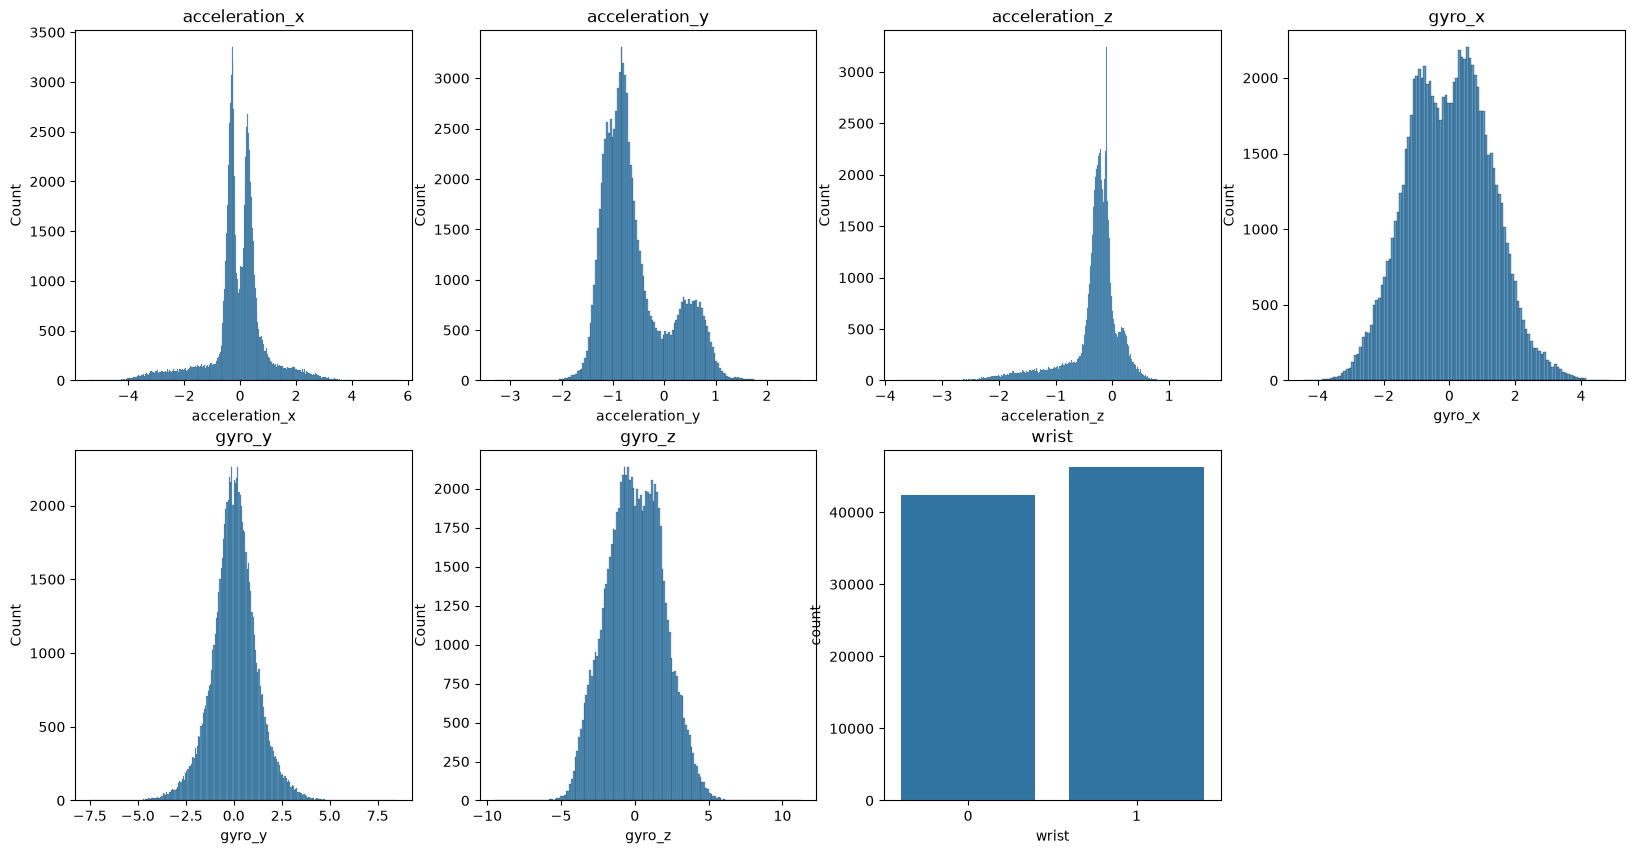

In [10]:
# Анализ признаков
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = [col for col in df.select_dtypes(include=['string', 'category', 'object']).columns.to_list() if col not in ['activity']]
cols = num_cols + cat_cols
print('Длина -', len(cols))
print(cols)

plt.figure(figsize=(20, 10))
for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    plt.title(col)

    if df[col].nunique() > 50:
        sns.histplot(x=df[col])
    else:
        sns.countplot(x=df[col])

plt.show()

<Axes: >

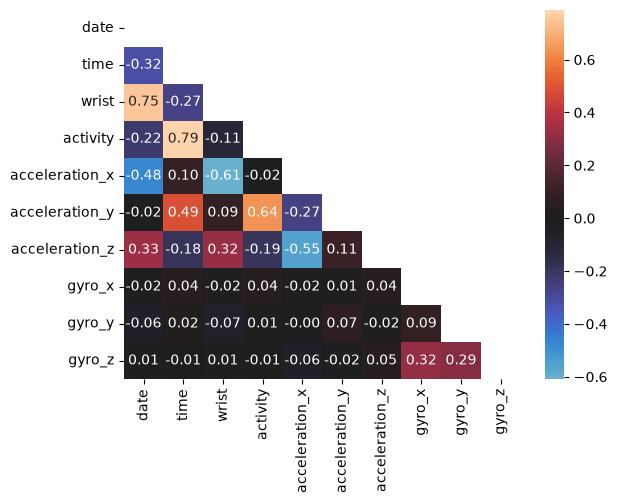

In [11]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, center=0, annot=True, fmt='.2f')

In [12]:
df.dtypes

date              datetime64[us]
time              datetime64[ns]
wrist                   category
activity                category
acceleration_x           float64
acceleration_y           float64
acceleration_z           float64
gyro_x                   float64
gyro_y                   float64
gyro_z                   float64
dtype: object

In [13]:
# Обработка признаков
df = df.drop(columns=['date', 'time'])
df['wrist'] = (df['wrist'] == '0').astype(int)

In [14]:
df

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...
88583,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [15]:
# Train, test split
X_cols = [col for col in df.columns if col not in ['activity']]
y_col = 'activity'

X, y = df[X_cols], df[y_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state']
)

## Оценка моделей

In [16]:
def evaluate(model, X_train, y_train, X_test, y_test):
    '''Считает метрики на Train, Test, Cross Validation'''

    model.fit(X_train, y_train)

    # Метркии на Train
    y_pred_train = model.predict(X_train)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train)
    recall_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)

    # Метркии на Test
    y_pred_test = model.predict(X_test)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)

    # Метрики на кросс валидации
    cv_scores = cross_validate(
        model, X_train, y_train,
        cv=CONFIG['cv_splits'],
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=False,
    )
    accuracy_cv = cv_scores['test_accuracy']
    precision_cv = cv_scores['test_precision_macro']
    recall_cv = cv_scores['test_recall_macro']
    f1_cv = cv_scores['test_f1_macro']

    # Результат
    eval_df = pd.DataFrame({
        # Метркии на Train
        'Train Accuracy': [accuracy_train],
        'Train Precision': [precision_train],
        'Train Recall': [recall_train],
        'Train F1': [f1_train],

        # Метркии на Train
        'Test Accuracy': [accuracy_test],
        'Test Precision': [precision_test],
        'Test Recall': [recall_test],
        'Test F1': [f1_test],

        # Метрики на кросс валидации
        'Mean Accuracy': [np.mean(accuracy_cv)],
        'Mean Precision': [np.mean(precision_cv)],
        'Mean Recall': [np.mean(recall_cv)],
        'Mean F1': [np.mean(f1_cv)],
    })

    return eval_df

In [17]:
evals_df = pd.DataFrame()

# Оценка моделей
for model_item in CONFIG['model'].items():
    name, model = model_item[0], model_item[1]

    # Evaluate
    print(f'Training {name}...')
    start = time.time()
    eval_df = evaluate(model, X_train, y_train, X_test, y_test)
    elapsed = time.time() - start

    # Result
    info_df = pd.DataFrame({
        'Model': [name],
        'Time': [elapsed],
    })
    eval_df = pd.concat([
        info_df,
        eval_df,
    ], axis=1)
    evals_df = pd.concat([evals_df, eval_df], axis=0)

Training naive...
Training linear...
Training knn...
Training svm...
Training random_forest...
Training xgboost...
Training lightgbm...
Training catboost...


In [18]:
evals_df.sort_values('Mean F1', ascending=False).reset_index(drop=True)

,Model,Time,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Mean Accuracy,Mean Precision,Mean Recall,Mean F1
0,catboost,33.4775,0.9968,0.9981,0.9954,0.9968,0.9914,0.9932,0.9896,0.9914,0.9911,0.9911,0.9911,0.9911
1,xgboost,1.1330,0.9983,0.9992,0.9974,0.9983,0.9912,0.9916,0.9907,0.9911,0.9908,0.9908,0.9908,0.9908
2,lightgbm,1.0755,0.9945,0.9961,0.9930,0.9945,0.9911,0.9917,0.9905,0.9911,0.9903,0.9903,0.9903,0.9903
3,random_forest,8.1679,1.0000,1.0000,1.0000,1.0000,0.9902,0.9897,0.9907,0.9902,0.9889,0.9889,0.9889,0.9889
4,svm,62.8864,0.9846,0.9905,0.9788,0.9846,0.9856,0.9907,0.9802,0.9854,0.9835,0.9836,0.9836,0.9835
5,knn,2.4216,0.9883,0.9956,0.9809,0.9882,0.9838,0.9931,0.9742,0.9835,0.9834,0.9835,0.9834,0.9834
6,linear,0.3132,0.8518,0.8862,0.8084,0.8455,0.8555,0.8871,0.8126,0.8482,0.8516,0.8543,0.8517,0.8513
7,naive,0.1319,0.7090,0.9987,0.4205,0.5918,0.7132,0.9981,0.4237,0.5949,0.7090,0.8150,0.7100,0.6828


## Выбор модели

In [19]:
name = 'linear'

# Обучение
model = CONFIG['model'][name]
model.fit(X_train, y_train)
# joblib.dump(model, f'model/{name}.pkl')

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Важность признаков

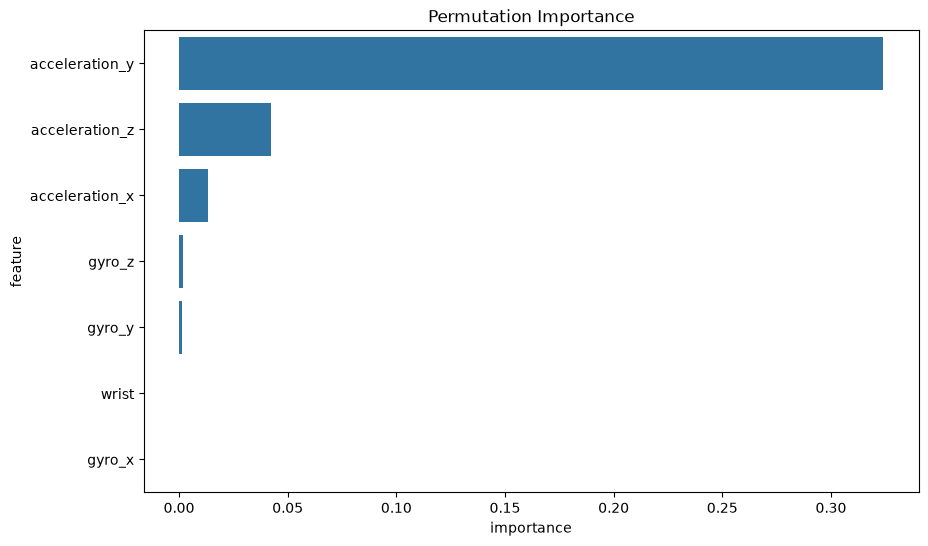

In [20]:
# Permutation importance
pi = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=CONFIG['pi_n_repeats'],
    random_state=CONFIG['random_state'],
    scoring='f1_macro'
)

pi = pd.DataFrame({
    'feature': X_test.columns,
    'importance': pi.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=pi.head(25), x='importance', y='feature')
plt.title(f'Permutation Importance')
plt.show()

## Выводы

- Все модели справились с задачей
- Для встаивания в фитнес устройство подойдут легкие модели (naive, linear)
- Наивный подход в 3 раза быстрее линейной модели, но уступает по метрикам
- Без признака времени модели выдают хорошие метрики